<div style="text-align:center; margin-top:40px;">

<img src="img/python_logo.png" width="600"/>

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-bottom:10px;
">

3_2_2_Transformaciones

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
">

July 14, 2026

</p>

<h2 style="
font-family:'Times New Roman', serif;
font-size:28px;
font-weight:bold;
margin-top:35px;
">

PAO26-26 - Transformaciones de imágenes

</h2>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-bottom:8px;
">

Kevin Xavier Suasnavas Villarreal

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:0px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">
<strong>Link a mi GitHub:</strong>
</a>

https://github.com/kevinsuas433/Machine2026.git

</p>

</div>

---

# 1 Lectura y transformación de imágenes

En esta práctica se estudiarán diferentes técnicas de procesamiento digital de imágenes utilizando **OpenCV**, **NumPy** y **Matplotlib**.

Durante el desarrollo del laboratorio se aprenderá a:

- Leer imágenes desde un archivo.
- Visualizar imágenes utilizando Matplotlib.
- Extraer los canales de color (RGB).
- Convertir entre diferentes espacios de color.
- Aplicar transformaciones de intensidad.
- Realizar transformaciones geométricas sobre imágenes.

Dimensiones de la imagen: (256, 256, 3)


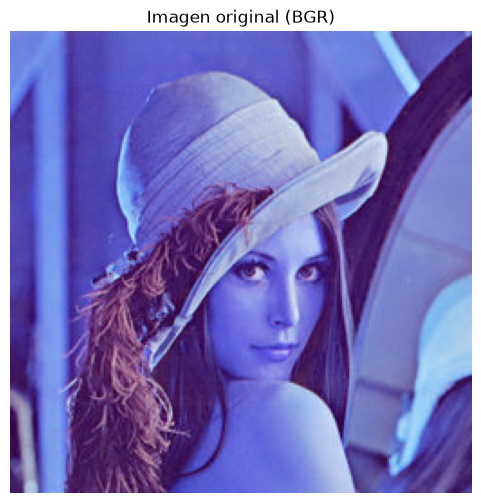

In [1]:
# ============================================================
# Lectura de una imagen utilizando OpenCV.
# ============================================================

# Si OpenCV no está instalado, ejecutar:
# pip install opencv-python

# Importar las bibliotecas necesarias.
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ============================================================
# Leer la imagen almacenada en la carpeta images.
# ============================================================

img = cv2.imread("images/Lena_RGB.png")

# ============================================================
# Mostrar las dimensiones de la imagen.
# ============================================================

print("Dimensiones de la imagen:", img.shape)

# ============================================================
# Mostrar la imagen utilizando Matplotlib.
#
# En este momento la imagen todavía se encuentra en formato BGR,
# por lo que los colores no se visualizarán correctamente.
# ============================================================

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Imagen original (BGR)")
plt.axis("off")
plt.show()

## Separación de los canales de color

Una imagen RGB está formada por tres canales independientes:

- **Rojo (Red)**
- **Verde (Green)**
- **Azul (Blue)**

Cada canal almacena la intensidad correspondiente a ese color.

Al visualizar cada canal por separado utilizando una escala de grises es posible observar qué zonas de la imagen contienen mayor intensidad para dicho color.

In [2]:
# ============================================================
# Extraer cada canal de color por separado.
#
# OpenCV almacena las imágenes en formato BGR:
# Canal 0 -> Blue
# Canal 1 -> Green
# Canal 2 -> Red
# ============================================================

R = img[:, :, 2]
G = img[:, :, 1]
B = img[:, :, 0]

### Visualización de los canales

A continuación se representa cada canal de la imagen en una subfigura diferente utilizando una escala de grises.

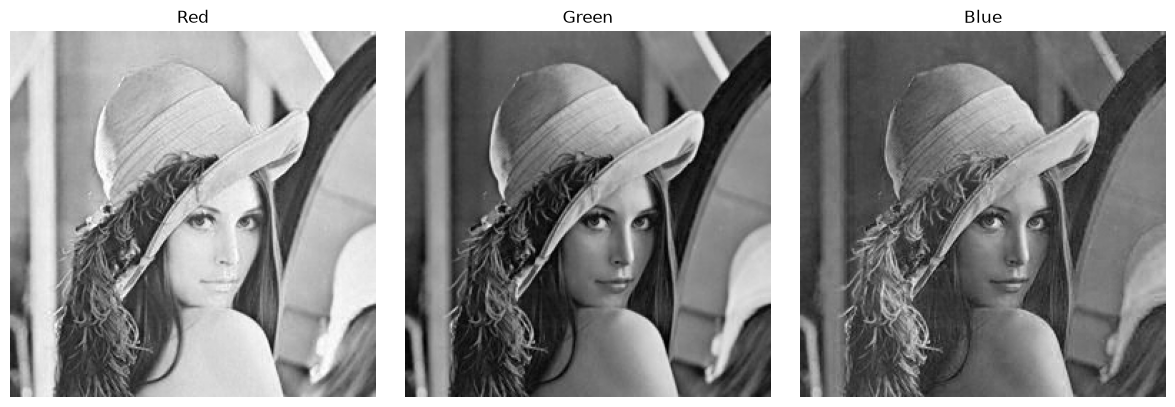

In [3]:
# ============================================================
# Mostrar los tres canales en una sola figura.
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(12,4))

# Canal rojo.
ax[0].imshow(R, cmap="gray")
ax[0].set_title("Red")
ax[0].axis("off")

# Canal verde.
ax[1].imshow(G, cmap="gray")
ax[1].set_title("Green")
ax[1].axis("off")

# Canal azul.
ax[2].imshow(B, cmap="gray")
ax[2].set_title("Blue")
ax[2].axis("off")

plt.tight_layout()

plt.show()

## Conversión del espacio de color

OpenCV utiliza el formato **BGR**, mientras que Matplotlib trabaja correctamente con imágenes en formato **RGB**.

Por este motivo es necesario convertir la imagen antes de visualizarla para que los colores aparezcan correctamente.

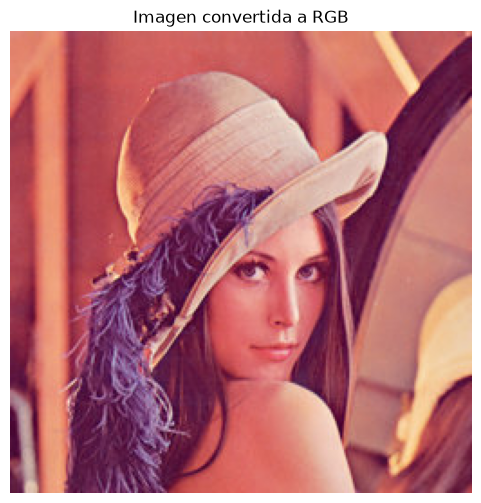

In [4]:
# ============================================================
# Convertir la imagen desde BGR hacia RGB.
# ============================================================

RGB_img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# ============================================================
# Mostrar la imagen con los colores correctos.
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(RGB_img)

plt.title("Imagen convertida a RGB")

plt.axis("off")

plt.show()

# 2 Transformaciones de intensidad

Las transformaciones de intensidad modifican los valores de los píxeles de una imagen sin alterar su posición.

Estas operaciones permiten mejorar la visualización de una imagen modificando características como:

- Brillo.
- Contraste.

En este apartado se utilizarán funciones de **OpenCV** para realizar estas transformaciones de forma segura, evitando errores de saturación de los valores de los píxeles.

## 2.1 Cambio de brillo

El brillo controla la cantidad de luz presente en una imagen.

Para incrementar o disminuir el brillo se suma o resta una constante a cada píxel.

OpenCV recomienda utilizar la función **cv2.add()**, ya que controla automáticamente que los valores permanezcan dentro del rango permitido (0–255).

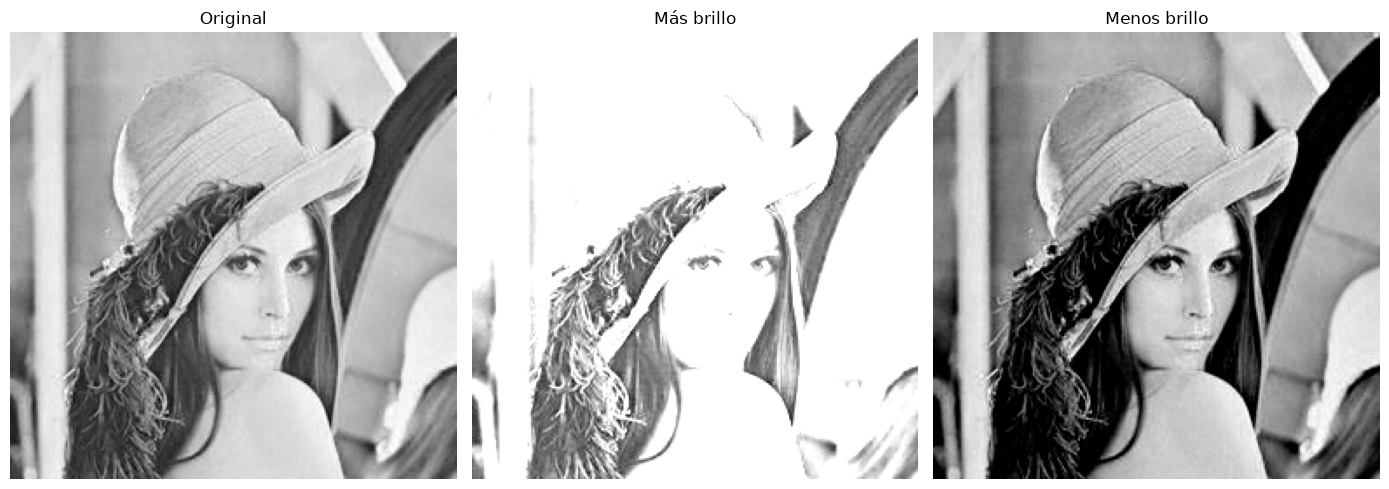

In [6]:
# ============================================================
# CAMBIO DE BRILLO
# ============================================================

# Leer nuevamente la imagen.
img = cv2.imread("images/Lena_RGB.png")

# Seleccionar únicamente el canal rojo.
img = img[:, :, 2]

# Definir cuánto brillo se desea aumentar o disminuir.
mas_brillo = 100
menos_brillo = -100

# ============================================================
# Aplicar las transformaciones.
#
# Se utiliza cv2.add() en lugar del operador "+"
# porque OpenCV controla automáticamente la saturación
# de los valores de los píxeles.
# ============================================================

mas_brillo_img = cv2.add(img, mas_brillo)

menos_brillo_img = cv2.add(img, menos_brillo)

# ============================================================
# Mostrar los resultados.
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(14,5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(mas_brillo_img, cmap="gray")
ax[1].set_title("Más brillo")
ax[1].axis("off")

ax[2].imshow(menos_brillo_img, cmap="gray")
ax[2].set_title("Menos brillo")
ax[2].axis("off")

plt.tight_layout()

plt.show()

## 2.2 Cambio de contraste

El contraste modifica la diferencia entre las zonas claras y oscuras de una imagen.

En este ejemplo se utiliza la misma fórmula empleada por el programa **GIMP**, la cual permite incrementar o disminuir el contraste mediante un parámetro comprendido entre **-100** y **100**.

La función **cv2.addWeighted()** aplica la transformación calculando automáticamente los nuevos valores de intensidad.

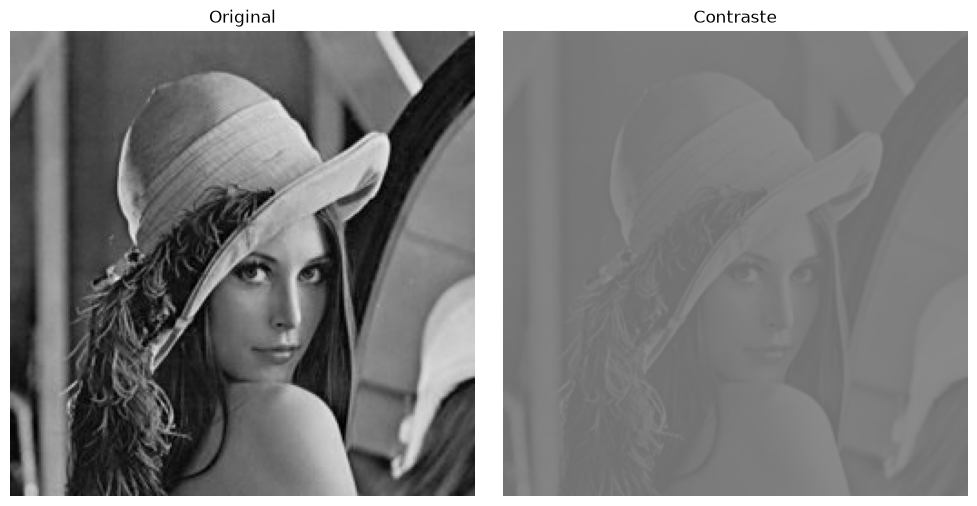

In [8]:
# ============================================================
# CAMBIO DE CONTRASTE
# ============================================================

# Leer nuevamente la imagen.
img = cv2.imread("images/Lena_RGB.png")

# Seleccionar únicamente el canal verde.
img = img[:, :, 1]

# Definir el nivel de contraste.
contraste = -100

# ============================================================
# Calcular los parámetros de la transformación.
#
# La siguiente fórmula corresponde al algoritmo
# utilizado por GIMP para modificar el contraste.
# ============================================================

f = 131 * (contraste + 127) / (127 * (131 - contraste))

alpha_c = f
gamma_c = 127 * (1 - f)

# ============================================================
# Aplicar el cambio de contraste.
# ============================================================

contrast_img = cv2.addWeighted(
    img,
    alpha_c,
    img,
    0,
    gamma_c
)

# ============================================================
# Mostrar la imagen original y la modificada.
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(contrast_img, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Contraste")
ax[1].axis("off")

plt.tight_layout()

plt.show()

# 3 Conversiones del espacio de color

Los espacios de color permiten representar una imagen utilizando diferentes modelos matemáticos según la aplicación.

Algunos de los espacios de color más utilizados son:

- **RGB:** utilizado en pantallas y dispositivos electrónicos.
- **CMYK:** utilizado en impresión.
- **HSV:** representa el color mediante tono, saturación y brillo.
- **Lab:** separa la luminosidad de la información del color.
- **YCrCb:** separa la luminancia de la crominancia, muy utilizado en procesamiento de video y compresión de imágenes.

En esta práctica se realizarán diferentes conversiones entre estos espacios de color utilizando **OpenCV** y **NumPy**.

## 3.1 Conversión de RGB a CMYK

El modelo **CMYK** (Cyan, Magenta, Yellow y Black) es el utilizado en impresión.

Las ecuaciones utilizadas son:

- K = 1 - max(R, G, B)
- C = (1 - R - K) / (1 - K)
- M = (1 - G - K) / (1 - K)
- Y = (1 - B - K) / (1 - K)

Posteriormente cada canal se representa de manera independiente.

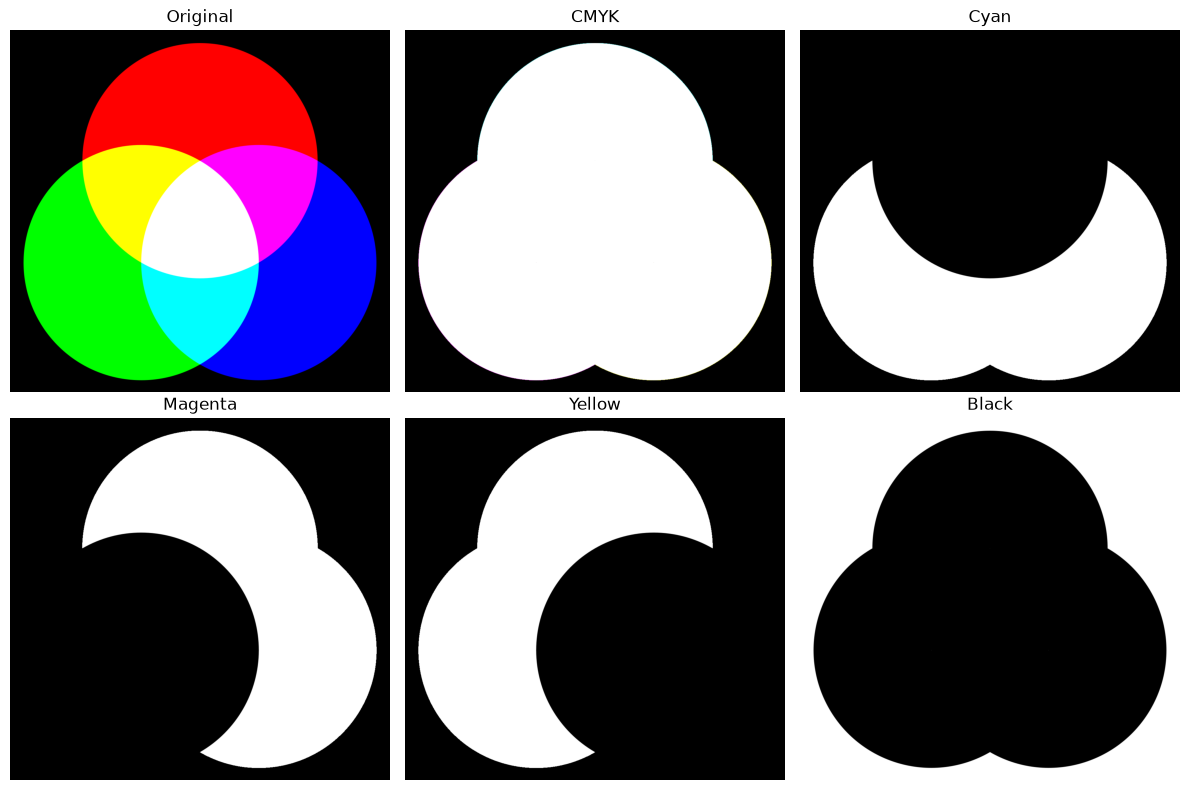

In [22]:
# ============================================================
# CONVERSIÓN DE RGB A CMYK
# ============================================================

# Importar las librerías necesarias.
import numpy as np
from skimage import io

# Leer la imagen.
img = io.imread("images/colores.png")

# Crear una copia para evitar modificar la imagen original.
rgb = img.copy()

# Convertir los valores de RGB al intervalo [0,1].
rgb_p = rgb.astype("float32") / 255

# ============================================================
# Calcular el canal negro (K).
# ============================================================

with np.errstate(divide="ignore", invalid="ignore"):

    # K corresponde al máximo nivel de tinta negra.
    K = 1 - np.max(rgb_p, axis=2)

    # ========================================================
    # Aplicar las ecuaciones de conversión RGB → CMYK.
    # ========================================================

    C = (1 - rgb_p[:, :, 0] - K) / (1 - K)

    M = (1 - rgb_p[:, :, 1] - K) / (1 - K)

    Y = (1 - rgb_p[:, :, 2] - K) / (1 - K)

    # Reemplazar posibles valores NaN por 0.
    C = np.nan_to_num(C)
    M = np.nan_to_num(M)
    Y = np.nan_to_num(Y)

# ============================================================
# Unir nuevamente los cuatro canales.
# ============================================================

CMYK = (np.dstack((C, M, Y, K)) * 255).astype("uint8")

# Separar cada canal para visualizarlo.
C, M, Y, K = cv2.split(CMYK)

# ============================================================
# Mostrar los resultados.
# ============================================================

fig, ax = plt.subplots(2, 3, figsize=(12,8))

ax[0,0].imshow(img)
ax[0,0].set_title("Original")
ax[0,0].axis("off")

ax[0,1].imshow(CMYK)
ax[0,1].set_title("CMYK")
ax[0,1].axis("off")

ax[0,2].imshow(C, cmap="gray")
ax[0,2].set_title("Cyan")
ax[0,2].axis("off")

ax[1,0].imshow(M, cmap="gray")
ax[1,0].set_title("Magenta")
ax[1,0].axis("off")

ax[1,1].imshow(Y, cmap="gray")
ax[1,1].set_title("Yellow")
ax[1,1].axis("off")

ax[1,2].imshow(K, cmap="gray")
ax[1,2].set_title("Black")
ax[1,2].axis("off")

plt.tight_layout()

plt.show()

## 3.2 Conversión entre diferentes espacios de color

OpenCV permite convertir una imagen entre múltiples espacios de color mediante la función **cv2.cvtColor()**.

En este ejemplo se obtendrán las siguientes representaciones:

- Escala de grises (Gray).
- HSV (Hue, Saturation y Value).
- Lab (Luminosidad y componentes de color).
- YCrCb (Luminancia y crominancia).

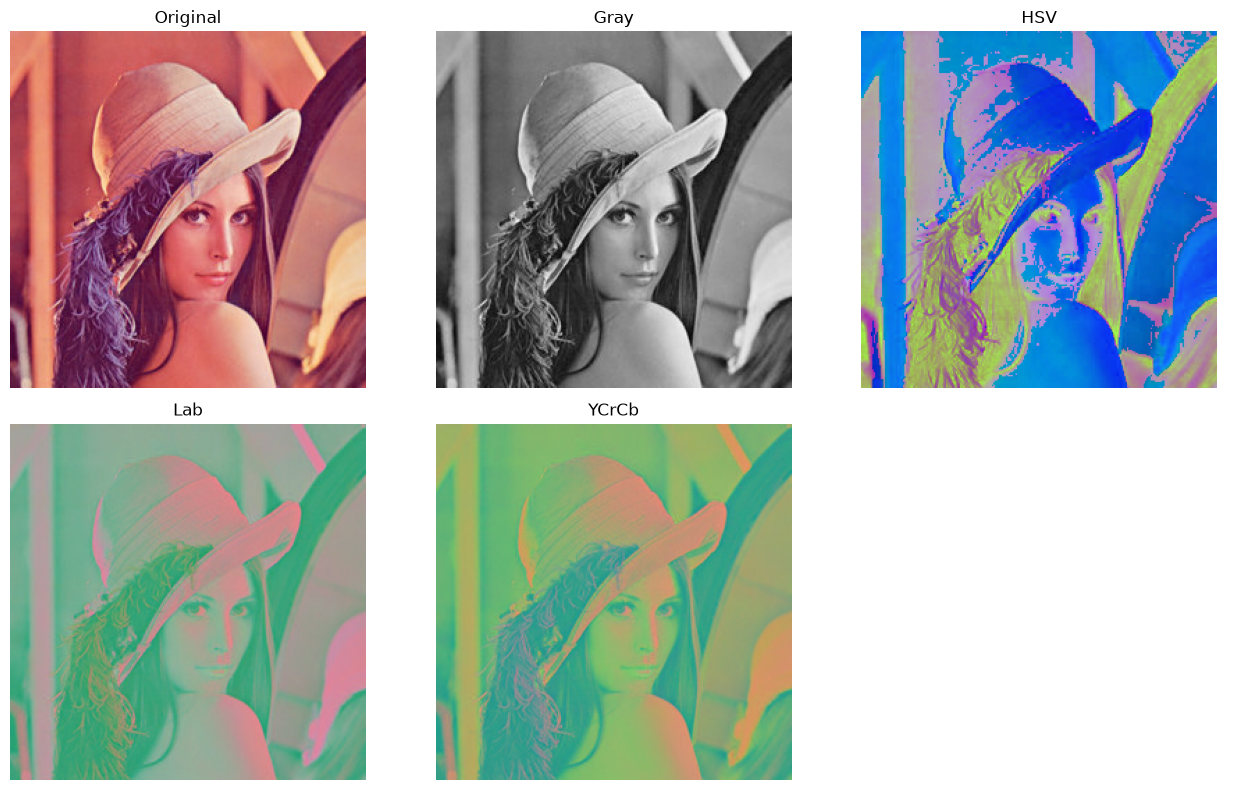

In [15]:
# ============================================================
# CONVERSIONES ENTRE ESPACIOS DE COLOR
# ============================================================

# Leer la imagen.
img = cv2.imread("images/Lena_RGB.png")

# ============================================================
# Convertir la imagen a diferentes espacios de color.
# ============================================================

# Escala de grises.
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Espacio HSV.
HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Espacio Lab.
Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

# Espacio YCrCb.
YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

# ============================================================
# Mostrar todas las conversiones.
# ============================================================

fig, ax = plt.subplots(2, 3, figsize=(13,8))

# Imagen original (convertida a RGB para visualizar correctamente).
ax[0,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0,0].set_title("Original")
ax[0,0].axis("off")

# Escala de grises.
ax[0,1].imshow(gray_img, cmap="gray")
ax[0,1].set_title("Gray")
ax[0,1].axis("off")

# HSV.
ax[0,2].imshow(HSV)
ax[0,2].set_title("HSV")
ax[0,2].axis("off")

# Lab.
ax[1,0].imshow(Lab)
ax[1,0].set_title("Lab")
ax[1,0].axis("off")

# YCrCb.
ax[1,1].imshow(YCrCb)
ax[1,1].set_title("YCrCb")
ax[1,1].axis("off")

# Dejar libre el último espacio.
ax[1,2].axis("off")

plt.tight_layout()

plt.show()

# 4 Transformaciones geométricas

Las transformaciones geométricas modifican la posición, orientación o tamaño de una imagen sin alterar la información de sus píxeles.

OpenCV proporciona diferentes funciones para realizar estas operaciones de forma sencilla.

En esta sección se aplicarán las siguientes transformaciones:

- Traslación.
- Recorte (Cropping).
- Rotación.
- Corrección de perspectiva.
- Volteo (Flipping).

## 4.1 Traslación

La traslación consiste en desplazar una imagen horizontal y/o verticalmente mediante una matriz de transformación afín.

La función **cv2.warpAffine()** aplica dicha transformación utilizando la matriz especificada.

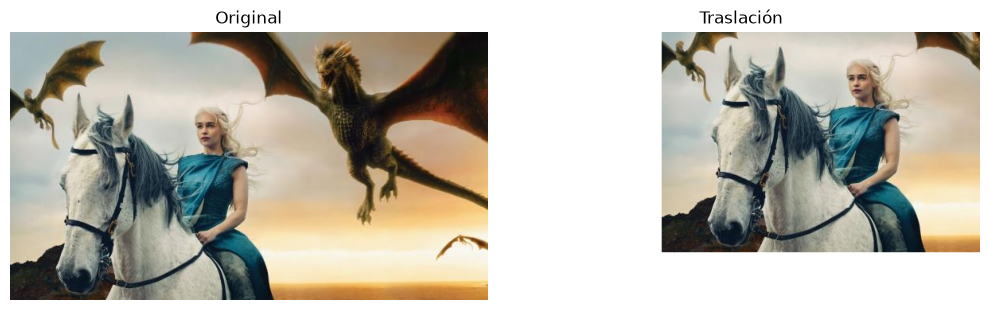

In [16]:
# ============================================================
# TRASLACIÓN
# ============================================================

# Leer la imagen.
img = io.imread("images/GOT.png")

# Obtener las dimensiones.
rows, cols, ch = img.shape

# Definir la matriz de traslación.
# Se desplaza 200 píxeles a la derecha y 60 hacia arriba.
M = np.float32([
    [1, 0, 200],
    [0, 1, -60]
])

# Aplicar la transformación.
new_img = cv2.warpAffine(img, M, (cols, rows))

# Mostrar resultados.
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(new_img)
ax[1].set_title("Traslación")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 4.2 Recorte (Cropping)

El recorte consiste en seleccionar únicamente una región de interés de la imagen utilizando índices de filas y columnas.

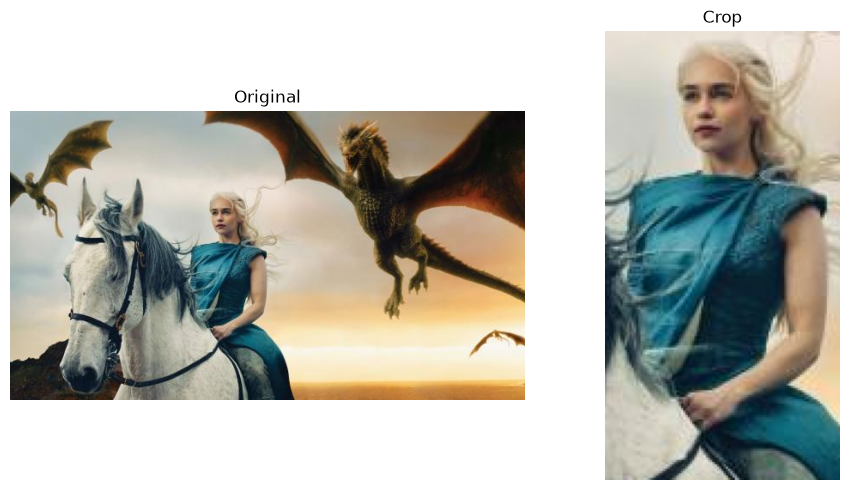

In [17]:
# ============================================================
# CROPPING
# ============================================================

# Leer la imagen.
img = io.imread("images/GOT.png")

# Seleccionar únicamente una región de la imagen.
new_img = img[90:290, 200:305]

# Mostrar resultados.
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(new_img)
ax[1].set_title("Crop")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 4.3 Rotación

La rotación modifica la orientación de la imagen alrededor de un punto determinado.

En este ejemplo se rota la imagen **90°** y además se incrementa su tamaño mediante un factor de escala igual a **2**.

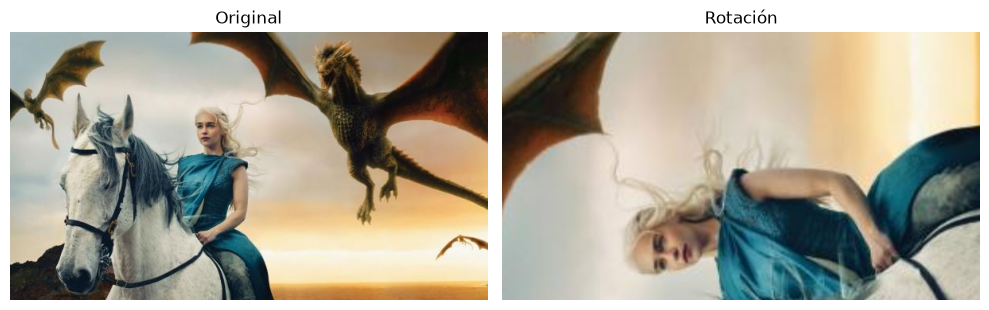

In [18]:
# ============================================================
# ROTACIÓN
# ============================================================

# Leer la imagen.
img = io.imread("images/GOT.png")

# Obtener dimensiones.
rows, cols, ch = img.shape

# Crear la matriz de rotación.
M = cv2.getRotationMatrix2D(
    center=(cols/2, rows/2),
    angle=90,
    scale=2
)

# Aplicar la transformación.
new_img = cv2.warpAffine(img, M, (cols, rows))

# Mostrar resultados.
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(new_img)
ax[1].set_title("Rotación")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 4.4 Transformación de perspectiva

La transformación de perspectiva permite corregir imágenes tomadas desde diferentes ángulos.

Para ello se seleccionan cuatro puntos de origen y cuatro puntos de destino, calculando una matriz de transformación mediante **cv2.getPerspectiveTransform()**.

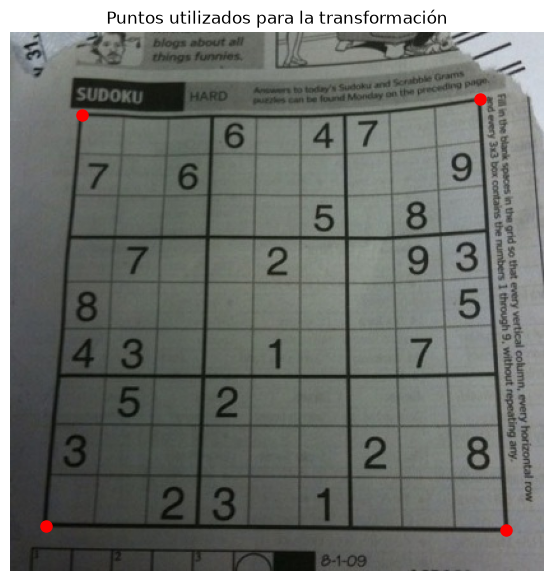

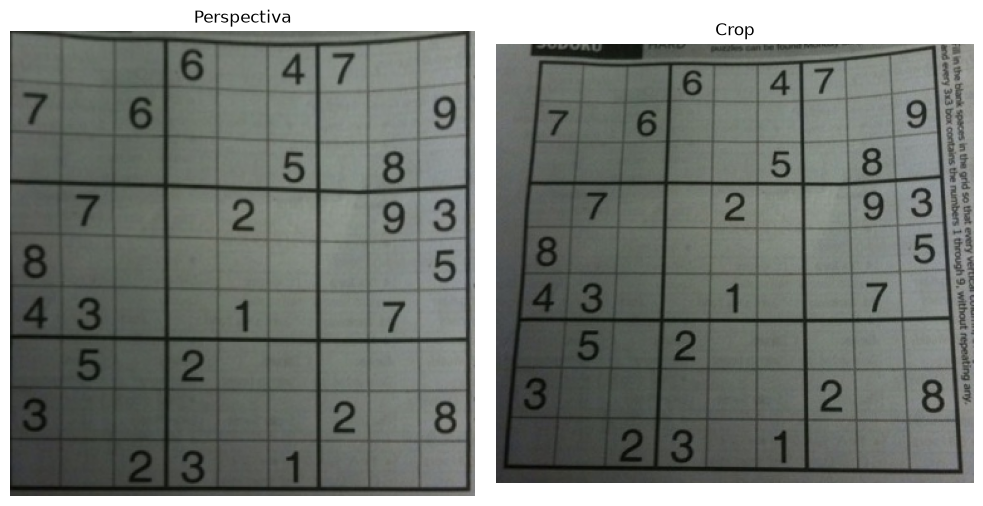

In [19]:
# ============================================================
# TRANSFORMACIÓN DE PERSPECTIVA
# ============================================================

# Leer la imagen.
img = cv2.imread("images/sudoku.png")

# Convertir BGR a RGB para visualizar correctamente.
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Obtener dimensiones.
rows, cols, ch = img.shape

# Definir los puntos originales.
pts1 = np.float32([
    [56,65],
    [368,52],
    [28,387],
    [389,390]
])

# Definir los puntos destino.
pts2 = np.float32([
    [0,0],
    [300,0],
    [0,300],
    [300,300]
])

# Mostrar los puntos seleccionados.
plt.figure(figsize=(7,7))
plt.imshow(img)

for punto in pts1:
    plt.plot(punto[0], punto[1], "or", markersize=8)

plt.title("Puntos utilizados para la transformación")
plt.axis("off")
plt.show()

# Calcular la matriz de perspectiva.
M = cv2.getPerspectiveTransform(pts1, pts2)

# Aplicar la transformación.
pers = cv2.warpPerspective(img, M, (305,305))

# Comparación con un recorte.
crop = img[50:400,20:400]

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(pers)
ax[0].set_title("Perspectiva")
ax[0].axis("off")

ax[1].imshow(crop)
ax[1].set_title("Crop")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 4.5 Flipping

El volteo o **Flipping** invierte la imagen respecto a un eje.

OpenCV permite realizar tres tipos de volteo:

- Vertical.
- Horizontal.
- Vertical y horizontal simultáneamente.

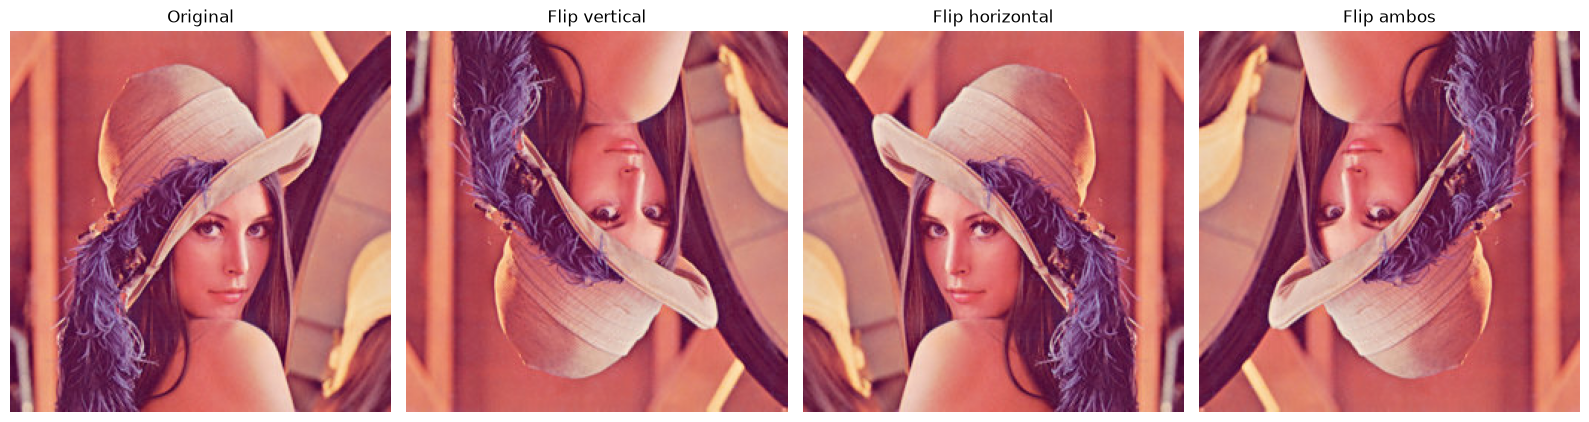

In [20]:
# ============================================================
# FLIPPING
# ============================================================

# Leer la imagen.
img = io.imread("images/Lena_RGB.png")

# ============================================================
# Realizar los diferentes tipos de volteo.
# ============================================================

# Volteo vertical.
flipVertical = cv2.flip(img, 0)

# Volteo horizontal.
flipHorizontal = cv2.flip(img, 1)

# Volteo vertical y horizontal.
flipBoth = cv2.flip(img, -1)

# ============================================================
# Mostrar todas las imágenes.
# ============================================================

fig, ax = plt.subplots(1,4, figsize=(16,5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(flipVertical)
ax[1].set_title("Flip vertical")
ax[1].axis("off")

ax[2].imshow(flipHorizontal)
ax[2].set_title("Flip horizontal")
ax[2].axis("off")

ax[3].imshow(flipBoth)
ax[3].set_title("Flip ambos")
ax[3].axis("off")

plt.tight_layout()
plt.show()